<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/notebooks/05_CAPITAL_ROTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/notebooks/05_CAPITAL_ROTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Customer journey:** Compare mature portfolio theses with available Quantvesting opportunity.


# Quantvesting

## End-to-End Run

The notebook is a thin client of the Quantvesting engine.

In [1]:
!pip install -q ta pyxirr matplotlib


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.4/532.4 kB 9.6 MB/s eta 0:00:00


In [2]:
# 1. Environment & imports

from google.colab import drive
drive.mount('/content/drive')

import sys

PROJECT = "/content/drive/My Drive/quantvesting_v3"
MARKET_DATA_DIR = PROJECT + "/market_data"
PORTFOLIO_ID = "vinod"
PORTFOLIO_DATA_DIR = PROJECT + f"/portfolio_data/{PORTFOLIO_ID}"

# Phase A controls
REFRESH_SCREENER = False   # True only when a new Screener XLSX has arrived
EOD_RUN = False            # True only for the final run of the day

sys.path.insert(0, PROJECT + "/src")

from quantvesting import (
    Quantvesting,
    load_config,
    load_market_data,
    load_portfolio_data,
    create_run_id,
    PROSPECT_DISPLAY_COLUMNS,
    PORTFOLIO_DISPLAY_COLUMNS,
)

RUN_ID = create_run_id()


Mounted at /content/drive


In [3]:
# 2. Load configuration and optionally refresh shared Screener data

config = load_config(
    PROJECT + "/config/strategy.yaml"
)

qv = Quantvesting(config)

if REFRESH_SCREENER:
    df_screener = qv.ingest_screener(MARKET_DATA_DIR)
    print(f"Screener CSV refreshed: {len(df_screener):,} securities")

market_data = load_market_data(MARKET_DATA_DIR)
portfolio_data = load_portfolio_data(
    PORTFOLIO_DATA_DIR,
    portfolio_id=PORTFOLIO_ID,
)


In [4]:
# 3. Prospect analysis

df_prospects = qv.prospects(
    market_data,
    portfolio_data=portfolio_data,
    include_portfolio=True,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)

qv.display_dataframe(
    df_prospects,
    columns=PROSPECT_DISPLAY_COLUMNS,
    sort_by="CumlRnk",
    ascending=True,
)


,Symbol,FTT,Dev%_200,Dev%_PE,Spread%,Conviction,Cyclical,RSI_14,RSP,FTT%,ATH%,Gained%,CumlRnk,ROE%/PE,Criteria,Strategy,Category,InFolio
0,INFY,1972.00,-12.21,-40.86,13.67,X-LC,NC,49.0,46.88,74.67,68.39,14.58,1.0,2.1,X40,NTT,IT,MAIN
1,TCS,4230.71,-9.36,-43.64,11.07,X-LC,NC,49.0,29.86,82.97,82.97,17.27,2.0,3.1,X40,ATH,IT,MAIN
2,TMPV,600.00,-10.19,-84.91,7.08,X-LC,DC,37.0,10.42,91.97,265.53,6.40,3.0,54.0,XY24,NTT,AUTO,NA
3,BSE,4391.73,4.03,-17.92,8.29,X-LC,NC,50.0,32.29,28.86,28.86,67.49,4.0,0.9,X40N,ATH,MISC,NA
4,HINDUNILVR,2922.00,-10.77,-43.44,8.36,X-LC,NC,36.0,30.90,48.17,47.56,0.51,5.0,1.0,XY25,NTT,FMCG,NA
5,ITC,452.00,-13.94,-31.98,11.93,X-LC,NC,40.0,15.45,71.08,75.61,3.41,6.0,1.8,X40,NTT,FMCG,NA
6,HCLTECH,1853.42,-4.07,-15.52,6.76,X-LC,NC,48.0,36.46,42.59,42.59,26.96,7.0,1.2,X40,ATH,IT,NA
7,HDFCBANK,1073.00,-13.62,-29.51,12.90,X-LC,NC,42.0,44.97,50.03,39.32,2.05,8.0,1.0,X40,BTT,BANKS,MAIN
8,VBL,669.42,-12.62,-32.14,9.06,X-LC,NC,38.0,25.35,63.35,63.35,7.58,9.0,0.4,X40N,ATH,FMCG,NA
9,RELIANCE,1952.00,-4.20,-5.96,5.91,X-LC,SC,56.0,78.12,47.12,19.46,5.40,10.0,0.4,XY25,BTT,REFINERIES,NA


,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
0,HDFCBANK,1.25,-56.64,49.97,-34.97,71507.0,-186900.0,143100.0,1073.00,-29.51,42.0,X-LC,12.90,26.0,-2.61,26.32,2.10,X40,BTT,BANKS
1,INFY,-0.12,-22.14,74.67,36.00,126454.0,-48150.0,169350.0,1972.00,-40.86,49.0,X-LC,13.67,3.0,-0.38,31.15,14.58,X40,NTT,IT
2,TCS,-0.33,-27.74,82.96,32.21,191837.0,-88760.0,231240.0,4230.71,-43.64,49.0,X-LC,11.07,2.0,-0.46,42.53,17.27,X40,ATH,IT


## Run date time (IST): 2026-09-04 13:43:47

Deployed:  8.68 L  
Current:  5.44 L  
CAGR/XIRR %: N/A

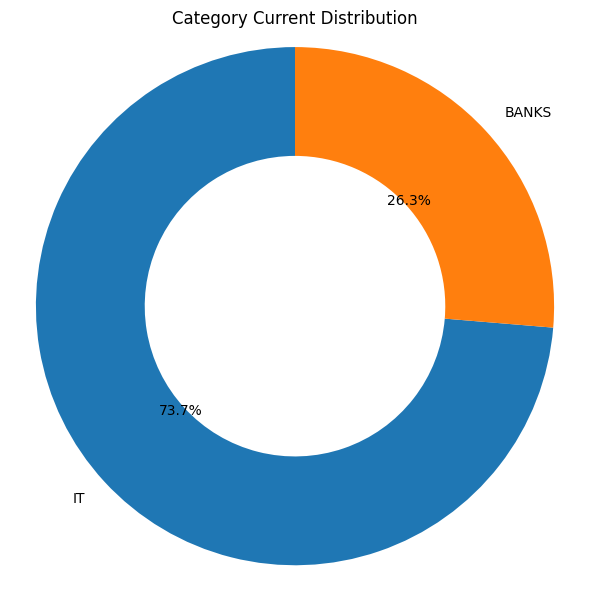

,Current
Category,
IT,400590.0
BANKS,143100.0


In [5]:
# 4. Portfolio analysis

df_portfolio, portfolio_summary = qv.portfolio(
    market_data,
    portfolio_data=portfolio_data,
    eod=EOD_RUN,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)

qv.display_dataframe(
    df_portfolio,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="FTT Amt",
    ascending=True,
)

qv.display_run_summary(portfolio_summary)

qv.display_portfolio_category_chart(
    df_portfolio,
    category_column="Category",
    value_column="Current",
    title="Category Current Distribution",
)


In [6]:
# 5. Decision layer

df_prospects_actions = qv.prospect_actions(
    df_prospects,
    top_n=10,
)

df_portfolio_actions = qv.portfolio_actions(
    df_portfolio,
)


## End of run

Calculations remain in the engine; notebook cells only orchestrate and present the results. The same structured outputs can later feed an API/Web UI.

In [7]:
# 6. Capital rotation review
# Advisory only: identifies holdings whose thesis is substantially captured
# and compares them with the best currently ranked CORE prospect.
df_rotation = qv.capital_rotation(
    df_prospects,
    df_portfolio,
)

if not df_rotation.empty:
    display(df_rotation)
else:
    print('No capital-rotation candidates at current thresholds.')


No capital-rotation candidates at current thresholds.


## Phase 2 — Premium investment terminal

In [8]:
qv.display_terminal(
    df_portfolio=df_portfolio,
    df_prospects=df_prospects,
    portfolio_summary=portfolio_summary,
    df_rotation=df_rotation,
    df_portfolio_actions=df_portfolio_actions,
    df_prospect_actions=df_prospects_actions,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
    run_datetime=portfolio_summary.get("run_datetime"),
)

qv.display_health_chart(df_portfolio)
qv.display_upside_chart(df_portfolio)
qv.display_prospect_opportunities(df_prospects)

## Capital Rotation — focused view

The engine's rotation layer is advisory: it identifies positions whose configured thesis-capture threshold has been reached and compares them with the best currently ranked CORE opportunity. It does **not** issue an automatic sell instruction.


In [9]:
# Focused rotation output
if df_rotation is None or df_rotation.empty:
    print("No capital-rotation candidates at the current configured thresholds.")
else:
    display(df_rotation)


No capital-rotation candidates at the current configured thresholds.
